# Лабораторна робота 1
## Лінійна регресія
**Горбач Ангеліна, ФІ-31**



## 1. Постановка задачі

Використано публічний набір [Vehicle Dataset from CarDekho](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho). Кожен рядок — це оголошення про продаж автомобіля. Мета роботи — прогнозувати ціну selling_price за характеристиками авто: віком, пробігом, маркою, типом пального та продавця, коробкою передач, кількістю власників і місць, витратою пального, об’ємом двигуна, потужністю та крутним моментом.

Повну назву моделі не використовую, бо унікальних назв забагато. Залишаю з неї лише марку.


In [ ]:
import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import importlib.util
import subprocess
import sys

if importlib.util.find_spec("xgboost") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])

    importlib.invalidate_caches()

from xgboost import XGBRegressor

np.random.seed(42)

warnings.filterwarnings("ignore", message="Found unknown categories")

sns.set_theme(style="whitegrid", palette="deep")

possible_paths = [Path("Car details v3.csv"), Path("/content/Car details v3.csv")]

data_path = next((path for path in possible_paths if path.exists()), None)


df_raw = pd.read_csv(data_path)

print(f"Кількість рядків: {df_raw.shape[0]}")
print(f"Кількість стовпців: {df_raw.shape[1]}")
df_raw.head()


Кількість рядків: 8128
Кількість стовпців: 13


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [2]:
initial_info = pd.DataFrame({
    "Тип даних": df_raw.dtypes.astype(str),
    "Пропуски": df_raw.isna().sum(),
    "Частка пропусків, %": (df_raw.isna().mean() * 100).round(2),
    "Унікальні значення": df_raw.nunique()
})

duplicate_count = int(df_raw.duplicated().sum())

print(f"Повністю однакових рядків: {duplicate_count}")
print("\nПропуски та типи даних:")
print(initial_info.to_string())

df_raw.describe().T.round(2)


Повністю однакових рядків: 1202

Пропуски та типи даних:
              Тип даних  Пропуски  Частка пропусків, %  Унікальні значення
name             object         0                 0.00                2058
year              int64         0                 0.00                  29
selling_price     int64         0                 0.00                 677
km_driven         int64         0                 0.00                 921
fuel             object         0                 0.00                   4
seller_type      object         0                 0.00                   3
transmission     object         0                 0.00                   2
owner            object         0                 0.00                   5
mileage          object       221                 2.72                 393
engine           object       221                 2.72                 121
max_power        object       215                 2.65                 322
torque           object       222          

,count,mean,std,min,25%,50%,75%,max
year,8128.0,2013.80,4.04,1983.0,2011.0,2015.0,2017.0,2020.0
selling_price,8128.0,638271.81,806253.40,29999.0,254999.0,450000.0,675000.0,10000000.0
km_driven,8128.0,69819.51,56550.55,1.0,35000.0,60000.0,98000.0,2360457.0
seats,7907.0,5.42,0.96,2.0,5.0,5.0,5.0,14.0


Дані потрібно очистити: у них є дублікати, пропуски та числа, записані разом з одиницями вимірювання. Окремо перевіряю `mileage`, `engine`, `max_power` і `torque`, а також шукаю аномально великі значення пробігу й ціни.


## 2. Очищення та підготовка даних

Під час очищення виконую такі кроки:

1. видаляю повні дублікати;
2. виділяю марку з назви автомобіля;
3. перетворюю рік випуску на вік автомобіля;
4. відділяю числові значення від одиниць вимірювання;
5. переводжу крутний момент із `kgm` у `Nm`;
6. нульові значення витрати пального та потужності вважаю пропусками;
7. видаляю один явно аномальний запис із пробігом понад мільйон кілометрів.

Пропуски заповню після поділу даних, використовуючи лише навчальну вибірку, щоб дані з тестової не вплинули на навчання.


In [ ]:
# Convert torque values to Nm
df = df_raw.copy()
df = df.drop_duplicates().reset_index(drop=True)

df["brand"] = df["name"].str.split().str[0]

reference_year = int(df["year"].max())

df["car_age"] = reference_year - df["year"]

df["mileage_unit"] = df["mileage"].str.extract(r"(kmpl|km/kg)", expand=False)

df["mileage_value"] = pd.to_numeric(
    df["mileage"].str.extract(r"([0-9.]+)", expand=False),
    errors="coerce"
)

df["engine_cc"] = pd.to_numeric(
    df["engine"].str.extract(r"([0-9.]+)", expand=False),
    errors="coerce"
)

df["max_power_bhp"] = pd.to_numeric(
    df["max_power"].str.extract(r"([0-9.]+)", expand=False),
    errors="coerce"
)

def parse_torque(value):

    if pd.isna(value):
        return np.nan

    text = str(value).lower().replace(",", "")

    match = re.search(r"([0-9.]+)", text)

    if match is None:
        return np.nan

    torque = float(match.group(1))

    if "kgm" in text:
        torque *= 9.80665

    return torque

df["torque_nm"] = df["torque"].apply(parse_torque)

df.loc[df["mileage_value"] <= 0, "mileage_value"] = np.nan

df.loc[df["max_power_bhp"] <= 0, "max_power_bhp"] = np.nan

rows_before_km_filter = len(df)

df = df[df["km_driven"] <= 1_000_000].reset_index(drop=True)

print(f"Видалено дублікатів: {duplicate_count}")
print(f"Видалено записів з аномальним пробігом: {rows_before_km_filter - len(df)}")
print(f"Залишилося рядків: {len(df)}")

clean_missing = df[[
    "mileage_value", "engine_cc", "max_power_bhp", "torque_nm", "seats"
]].isna().sum()

print("\nПропуски після перетворення:")
print(clean_missing.to_string())


Видалено дублікатів: 1202
Видалено записів з аномальним пробігом: 2
Залишилося рядків: 6924

Пропуски після перетворення:
mileage_value    223
engine_cc        208
max_power_bhp    209
torque_nm        209
seats            208


## 3. Дослідницький аналіз даних


Асиметрія початкової ціни: 5.57
Асиметрія після логарифмування: -0.16


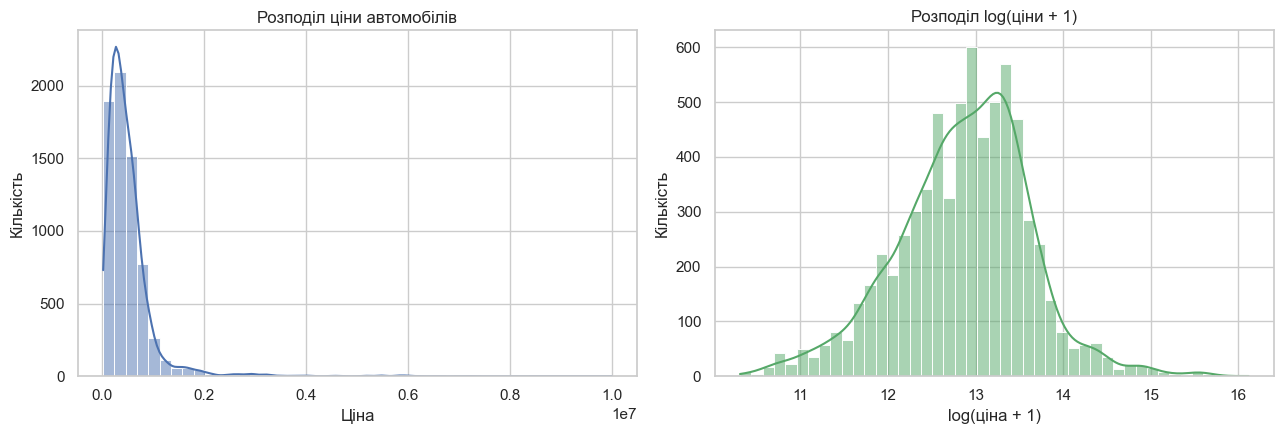

In [4]:
log_price = np.log1p(df["selling_price"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["selling_price"], bins=45, kde=True, ax=axes[0], color="#4C72B0")

axes[0].set_title("Розподіл ціни автомобілів")
axes[0].set_xlabel("Ціна")
axes[0].set_ylabel("Кількість")

sns.histplot(log_price, bins=45, kde=True, ax=axes[1], color="#55A868")

axes[1].set_title("Розподіл log(ціни + 1)")
axes[1].set_xlabel("log(ціна + 1)")
axes[1].set_ylabel("Кількість")

print(f"Асиметрія початкової ціни: {df['selling_price'].skew():.2f}")
print(f"Асиметрія після логарифмування: {log_price.skew():.2f}")

plt.tight_layout()
plt.show()


У даних є кілька автомобілів із дуже високою ціною. Логарифмування зменшує їхній вплив, тому моделі прогнозуватимуть `log(selling_price + 1)`. Перед оцінюванням результатів переведу прогнози назад у грошові одиниці.


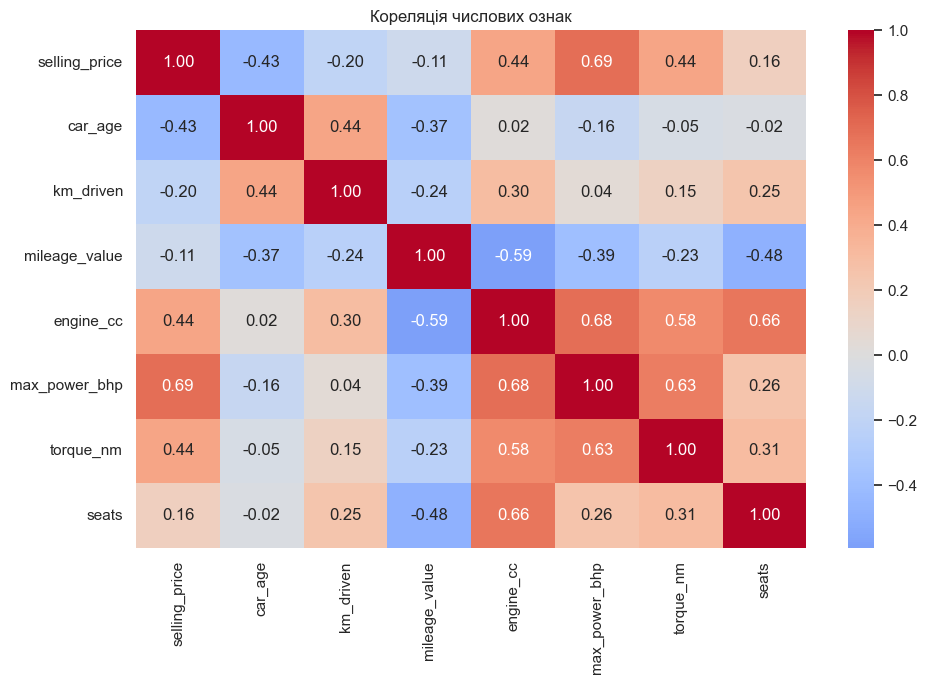

max_power_bhp    0.692
torque_nm        0.443
engine_cc        0.443
car_age         -0.433
km_driven       -0.199
seats            0.158
mileage_value   -0.108
Name: selling_price, dtype: float64

In [5]:
numeric_for_analysis = [
    "selling_price", "car_age", "km_driven", "mileage_value",
    "engine_cc", "max_power_bhp", "torque_nm", "seats"
]

correlation_matrix = df[numeric_for_analysis].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Кореляція числових ознак")
plt.tight_layout()
plt.show()

price_correlations = correlation_matrix["selling_price"].drop("selling_price")
price_correlations = price_correlations.reindex(price_correlations.abs().sort_values(ascending=False).index)

price_correlations.round(3)


### Висновок після аналізу

Вища ціна зазвичай пов’язана з більшою потужністю, об’ємом двигуна та крутним моментом. Старші автомобілі переважно дешевші. Оскільки показники двигуна тісно пов’язані між собою, звичайна лінійна регресія може бути нестійкою. Тому я також перевіряю Ridge і Lasso з регуляризацією.


## 4. Формування навчальної та тестової вибірок

Ділю дані на 70% для навчання і 30% для тестування. Частину навчальних даних використовую для підбору параметрів. Тестові дані залишаю для остаточної перевірки моделей.


In [6]:
numeric_features = [
    "car_age", "km_driven", "mileage_value", "engine_cc",
    "max_power_bhp", "torque_nm", "seats"
]

categorical_features = [
    "brand", "fuel", "seller_type", "transmission", "owner", "mileage_unit"
]

X = df[numeric_features + categorical_features].copy()

y = np.log1p(df["selling_price"].to_numpy())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_fit, X_valid, y_fit, y_valid = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))
])

preprocessor_selection = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_fit_processed = preprocessor_selection.fit_transform(X_fit)

X_valid_processed = preprocessor_selection.transform(X_valid)

print(f"Навчальна вибірка: {len(X_train)} рядків")
print(f"Тестова вибірка: {len(X_test)} рядків")
print(f"Ознак після кодування: {X_fit_processed.shape[1]}")


Навчальна вибірка: 4846 рядків
Тестова вибірка: 2078 рядків
Ознак після кодування: 45


## 5. Власні реалізації моделей

**OLS.** Обчислюю коефіцієнти через псевдообернену матрицю: $\hat{\beta}=X^{+}y$. Це дає змогу працювати й тоді, коли ознаки взаємозалежні.

**Ridge.** Додаю штраф за великі коефіцієнти: $\hat{\beta}=(X^TX+\alpha I)^{-1}X^Ty$. Вільний член не штрафую.

**Lasso.** Також штрафує великі коефіцієнти, але може зробити деякі з них нульовими. Для навчання по черзі оновлюю коефіцієнти методом координатного спуску.


In [7]:
class ManualLinearRegression:

    def fit(self, X, y):

        X_with_intercept = np.column_stack([np.ones(len(X)), X])

        self.coef_full_ = np.dot(np.linalg.pinv(X_with_intercept), y)

        self.intercept_ = self.coef_full_[0]

        self.coef_ = self.coef_full_[1:]

        return self

    def predict(self, X):

        X_with_intercept = np.column_stack([np.ones(len(X)), X])

        return np.dot(X_with_intercept, self.coef_full_)

class ManualRidgeRegression:

    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):

        X_with_intercept = np.column_stack([np.ones(len(X)), X])

        penalty = np.eye(X_with_intercept.shape[1])

        penalty[0, 0] = 0

        left_part = np.dot(X_with_intercept.T, X_with_intercept) + self.alpha * penalty
        right_part = np.dot(X_with_intercept.T, y)
        self.coef_full_ = np.dot(np.linalg.pinv(left_part), right_part)

        self.intercept_ = self.coef_full_[0]
        self.coef_ = self.coef_full_[1:]

        return self

    def predict(self, X):

        X_with_intercept = np.column_stack([np.ones(len(X)), X])

        return np.dot(X_with_intercept, self.coef_full_)


In [8]:
# Coordinate descent with soft-thresholding
def soft_threshold(value, threshold):

    return np.sign(value) * max(abs(value) - threshold, 0.0)

class ManualLassoRegression:

    def __init__(self, alpha=0.001, max_iter=3000, tol=1e-7):
        self.alpha = alpha
        self.max_iter = max_iter
        self.tol = tol

    def fit(self, X, y):

        self.x_mean_ = X.mean(axis=0)
        self.y_mean_ = y.mean()

        X_centered = X - self.x_mean_
        y_centered = y - self.y_mean_

        coefficients = np.zeros(X.shape[1])

        column_norms = np.mean(X_centered ** 2, axis=0)

        current_prediction = np.dot(X_centered, coefficients)

        for iteration in range(self.max_iter):

            old_coefficients = coefficients.copy()

            for column in range(X.shape[1]):

                residual = y_centered - current_prediction + X_centered[:, column] * coefficients[column]

                correlation = np.mean(X_centered[:, column] * residual)

                new_coefficient = soft_threshold(correlation, self.alpha) / (column_norms[column] + 1e-12)

                current_prediction += X_centered[:, column] * (new_coefficient - coefficients[column])

                coefficients[column] = new_coefficient

            max_change = np.max(np.abs(coefficients - old_coefficients))

            if max_change < self.tol:
                break

        self.coef_ = coefficients

        self.intercept_ = self.y_mean_ - np.dot(self.x_mean_, self.coef_)

        self.n_iter_ = iteration + 1

        return self

    def predict(self, X):

        return self.intercept_ + np.dot(X, self.coef_)


In [9]:
# Coarse search followed by local refinement
def restore_price(log_predictions):
    return np.maximum(np.expm1(log_predictions), 0)


def validation_rmse(y_true_log, y_pred_log):
    y_true_price = np.expm1(y_true_log)
    y_pred_price = restore_price(y_pred_log)
    return np.sqrt(mean_squared_error(y_true_price, y_pred_price))


def evaluate_ridge_alphas(alphas):
    rows = []
    for alpha in alphas:
        model = ManualRidgeRegression(alpha=alpha).fit(X_fit_processed, y_fit)
        rmse = validation_rmse(y_valid, model.predict(X_valid_processed))
        rows.append((alpha, rmse))
    return pd.DataFrame(rows, columns=["alpha", "RMSE на валідації"])


def evaluate_lasso_alphas(alphas):
    rows = []
    for alpha in alphas:
        model = ManualLassoRegression(alpha=alpha, max_iter=5000).fit(X_fit_processed, y_fit)
        rmse = validation_rmse(y_valid, model.predict(X_valid_processed))
        rows.append((alpha, rmse, model.n_iter_))
    return pd.DataFrame(rows, columns=["alpha", "RMSE на валідації", "Ітерації"])


ridge_coarse = evaluate_ridge_alphas([0.001, 0.01, 0.1, 1, 10, 100])
ridge_fine = evaluate_ridge_alphas([0.02, 0.05, 0.1, 0.2, 0.5])
ridge_selection = pd.concat([ridge_coarse, ridge_fine], ignore_index=True).drop_duplicates("alpha").sort_values("alpha").reset_index(drop=True)
best_ridge_alpha = float(ridge_selection.loc[ridge_selection["RMSE на валідації"].idxmin(), "alpha"])

lasso_coarse = evaluate_lasso_alphas([0.0001, 0.0003, 0.001, 0.003, 0.01])
lasso_fine = evaluate_lasso_alphas([0.00005, 0.00007, 0.0001, 0.00015, 0.0002])
lasso_selection = pd.concat([lasso_coarse, lasso_fine], ignore_index=True).drop_duplicates("alpha").sort_values("alpha").reset_index(drop=True)
best_lasso_alpha = float(lasso_selection.loc[lasso_selection["RMSE на валідації"].idxmin(), "alpha"])

print(f"Найкраще alpha для Ridge: {best_ridge_alpha}")
print(ridge_selection.to_string(index=False))
print(f"\nНайкраще alpha для Lasso: {best_lasso_alpha}")
print(lasso_selection.to_string(index=False))


Найкраще alpha для Ridge: 0.2
  alpha  RMSE на валідації
  0.001      220455.219877
  0.010      220447.713624
  0.020      220436.186169
  0.050      220388.460398
  0.100      220295.150949
  0.200      220142.732389
  0.500      220143.893691
  1.000      221138.994230
 10.000      241200.376190
100.000      274530.370077

Найкраще alpha для Lasso: 7e-05
  alpha  RMSE на валідації  Ітерації
0.00005      216832.828853       994
0.00007      216670.342562       206
0.00010      217451.699850       262
0.00015      221560.448053       713
0.00020      227881.985523       620
0.00030      242900.132055        66
0.00100      265088.645584        58
0.00300      278918.615341        64
0.01000      304127.964028        46


### Обґрунтування параметрів регуляризації

Я перевірила різні значення `alpha`: спочатку в широкому діапазоні, потім поблизу найкращого результату. Для кожного значення порівняла RMSE на валідаційних даних. Найменшу помилку отримала при `alpha=0.2` для Ridge та `alpha=0.00007` для Lasso.


## 6. Навчання та оцінювання власних моделей

Після вибору `alpha` повторно готую всі 70% навчальних даних і навчаю на них моделі. Обчислюю MAE, RMSE та $R^2$ на навчальній і тестовій вибірках, щоб оцінити точність і перевірити, чи немає перенавчання. Також порівнюю час навчання моделей.


In [10]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

y_train_price = np.expm1(y_train)
y_test_price = np.expm1(y_test)

def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {"MAE": mae, "RMSE": rmse, "R2": r2}

manual_models = {
    "Власна OLS": ManualLinearRegression(),
    "Власна Ridge": ManualRidgeRegression(alpha=best_ridge_alpha),
    "Власна Lasso": ManualLassoRegression(alpha=best_lasso_alpha, max_iter=5000)
}

manual_results = []
manual_predictions = {}

for model_name, model in manual_models.items():

    start_time = time.perf_counter()
    model.fit(X_train_processed, y_train)
    fit_time = time.perf_counter() - start_time

    train_prediction = restore_price(model.predict(X_train_processed))
    test_prediction = restore_price(model.predict(X_test_processed))

    manual_predictions[model_name] = test_prediction

    train_metrics = calculate_metrics(y_train_price, train_prediction)
    test_metrics = calculate_metrics(y_test_price, test_prediction)

    manual_results.append({
        "Модель": model_name,
        "Train MAE": train_metrics["MAE"],
        "Test MAE": test_metrics["MAE"],
        "Train RMSE": train_metrics["RMSE"],
        "Test RMSE": test_metrics["RMSE"],
        "Train R2": train_metrics["R2"],
        "Test R2": test_metrics["R2"],
        "Час, с": fit_time
    })

manual_results = pd.DataFrame(manual_results)

manual_results.round({
    "Train MAE": 0, "Test MAE": 0,
    "Train RMSE": 0, "Test RMSE": 0,
    "Train R2": 4, "Test R2": 4, "Час, с": 4
})


,Модель,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,"Час, с"
0,Власна OLS,93998.0,94039.0,173534.0,189377.0,0.8835,0.8795,0.0256
1,Власна Ridge,94080.0,94756.0,174090.0,192791.0,0.8827,0.8751,0.0064
2,Власна Lasso,94347.0,95645.0,174850.0,197342.0,0.8817,0.8691,8.0846


## 7. Порівняння з готовими реалізаціями

Готові моделі використовую тільки для перевірки власного коду. Для коректного порівняння передаю їм ті самі навчальні дані та ті самі значення `alpha`.


In [11]:
sklearn_models = {
    "sklearn OLS": LinearRegression(),
    "sklearn Ridge": Ridge(alpha=best_ridge_alpha),
    "sklearn Lasso": Lasso(alpha=best_lasso_alpha, max_iter=10000, tol=1e-7)
}

matching_manual_names = {
    "sklearn OLS": "Власна OLS",
    "sklearn Ridge": "Власна Ridge",
    "sklearn Lasso": "Власна Lasso"
}

sklearn_results = []

for model_name, model in sklearn_models.items():

    start_time = time.perf_counter()
    model.fit(X_train_processed, y_train)
    fit_time = time.perf_counter() - start_time

    test_prediction = restore_price(model.predict(X_test_processed))

    metrics = calculate_metrics(y_test_price, test_prediction)

    manual_name = matching_manual_names[model_name]
    max_difference = np.max(np.abs(test_prediction - manual_predictions[manual_name]))

    sklearn_results.append({
        "Модель": model_name,
        "Test MAE": metrics["MAE"],
        "Test RMSE": metrics["RMSE"],
        "Test R2": metrics["R2"],
        "Час, с": fit_time,
        "Макс. різниця з власною моделлю": max_difference
    })

sklearn_results = pd.DataFrame(sklearn_results)
sklearn_results.round({
    "Test MAE": 0, "Test RMSE": 0, "Test R2": 4,
    "Час, с": 4, "Макс. різниця з власною моделлю": 2
})


,Модель,Test MAE,Test RMSE,Test R2,"Час, с",Макс. різниця з власною моделлю
0,sklearn OLS,94039.0,189377.0,0.8795,0.2385,0.00
1,sklearn Ridge,94756.0,192791.0,0.8751,0.0050,0.00
2,sklearn Lasso,95645.0,197342.0,0.8691,0.5113,2.31


## 8. Порівняння з XGBoost

XGBoost використовую, щоб порівняти лінійні моделі з нелінійною. На валідаційних даних перевіряю кількість дерев (`n_estimators`: 300 або 600), їхню глибину (`max_depth`: 3 або 5) і внесок кожного дерева (`learning_rate`: 0.03 або 0.05).

Кожне дерево використовує 80% об’єктів і ознак, що допомагає уникати перенавчання. `objective="reg:squarederror"` задає задачу регресії, а `random_state=42` забезпечує однаковий результат при повторному запуску. Обираю параметри з найменшим валідаційним RMSE і навчаю модель на всіх 70% навчальних даних.



In [12]:
# Tune XGBoost on the validation subset
xgb_rows = []

for n_estimators in [300, 600]:
    for max_depth in [3, 5]:
        for learning_rate in [0.03, 0.05]:
            model = XGBRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                learning_rate=learning_rate,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
            model.fit(X_fit_processed, y_fit)
            rmse = validation_rmse(y_valid, model.predict(X_valid_processed))
            xgb_rows.append((n_estimators, max_depth, learning_rate, rmse))

xgb_selection = pd.DataFrame(
    xgb_rows,
    columns=["n_estimators", "max_depth", "learning_rate", "RMSE на валідації"]
).sort_values("RMSE на валідації")

best_xgb_params = xgb_selection.iloc[0]

xgb_model = XGBRegressor(
    n_estimators=int(best_xgb_params["n_estimators"]),
    max_depth=int(best_xgb_params["max_depth"]),
    learning_rate=float(best_xgb_params["learning_rate"]),
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

start_time = time.perf_counter()
xgb_model.fit(X_train_processed, y_train)
xgb_fit_time = time.perf_counter() - start_time

xgb_train_prediction = restore_price(xgb_model.predict(X_train_processed))
xgb_test_prediction = restore_price(xgb_model.predict(X_test_processed))
xgb_train_metrics = calculate_metrics(y_train_price, xgb_train_prediction)
xgb_test_metrics = calculate_metrics(y_test_price, xgb_test_prediction)

print("Найкращі комбінації параметрів:")
print(xgb_selection.head().to_string(index=False))
print("\nРезультат найкращої моделі XGBoost:")
print(f"Train RMSE = {xgb_train_metrics['RMSE']:.0f}")
print(f"Test RMSE = {xgb_test_metrics['RMSE']:.0f}")
print(f"Test MAE = {xgb_test_metrics['MAE']:.0f}")
print(f"Test R² = {xgb_test_metrics['R2']:.4f}")
print(f"Час навчання = {xgb_fit_time:.3f} с")


Найкращі комбінації параметрів:
 n_estimators  max_depth  learning_rate  RMSE на валідації
          600          3           0.05      286015.694209
          600          5           0.03      288553.082776
          600          5           0.05      290103.298823
          300          5           0.05      290395.853405
          300          3           0.05      290448.653996

Результат найкращої моделі XGBoost:
Train RMSE = 117843
Test RMSE = 150496
Test MAE = 75002
Test R² = 0.9239
Час навчання = 1.754 с


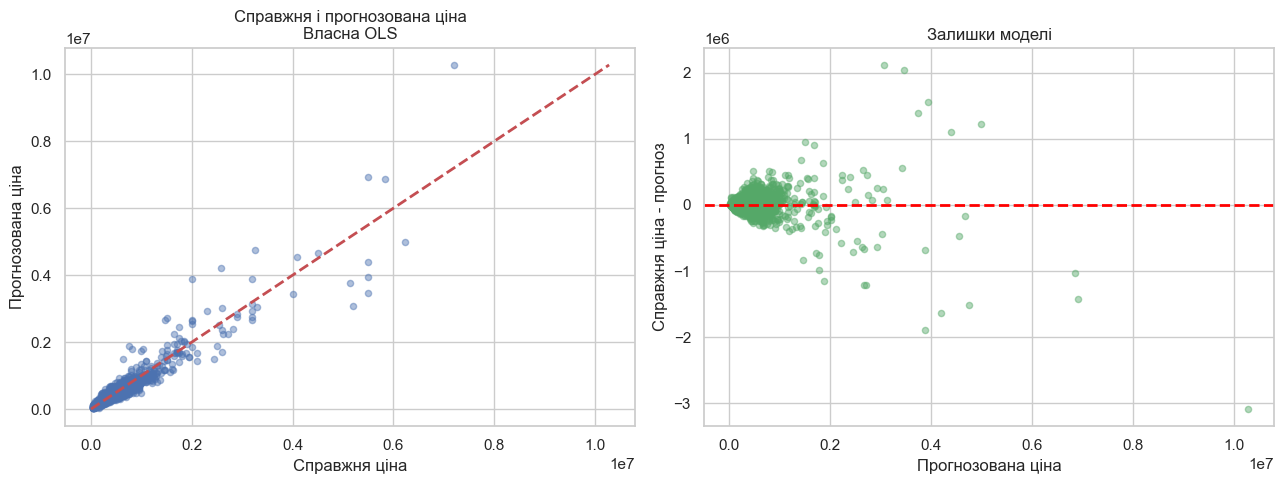

In [13]:
best_manual_name = manual_results.loc[manual_results["Test RMSE"].idxmin(), "Модель"]

best_prediction = manual_predictions[best_manual_name]

residuals = y_test_price - best_prediction

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test_price, best_prediction, alpha=0.45, s=20)

price_limit = max(y_test_price.max(), best_prediction.max())
axes[0].plot([0, price_limit], [0, price_limit], "r--", linewidth=2)
axes[0].set_title(f"Справжня і прогнозована ціна\n{best_manual_name}")
axes[0].set_xlabel("Справжня ціна")
axes[0].set_ylabel("Прогнозована ціна")

axes[1].scatter(best_prediction, residuals, alpha=0.45, s=20, color="#55A868")
axes[1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_title("Залишки моделі")
axes[1].set_xlabel("Прогнозована ціна")
axes[1].set_ylabel("Справжня ціна - прогноз")

plt.tight_layout()
plt.show()


In [ ]:

best_row = manual_results.loc[manual_results["Test RMSE"].idxmin()]
lasso_nonzero = int(np.count_nonzero(manual_models["Власна Lasso"].coef_))
rmse_gap = best_row["Test RMSE"] - best_row["Train RMSE"]

print("Підсумок роботи")
print(f"1. Найкраща власна модель: {best_row['Модель']}.")
print(f"2. Train RMSE = {best_row['Train RMSE']:.0f}, Test RMSE = {best_row['Test RMSE']:.0f}.")
print(f"3. На тесті MAE = {best_row['Test MAE']:.0f}, R² = {best_row['Test R2']:.4f}.")
print(f"4. Для Ridge вибрано alpha = {best_ridge_alpha}, для Lasso - alpha = {best_lasso_alpha}.")
print(f"5. Lasso залишила {lasso_nonzero} ненульових коефіцієнтів із {len(manual_models['Власна Lasso'].coef_)}.")
print(f"6. Різниця між тестовим і навчальним RMSE становить {rmse_gap:.0f}.")
print(f"7. XGBoost після підбору параметрів: Test RMSE = {xgb_test_metrics['RMSE']:.0f}, R² = {xgb_test_metrics['R2']:.4f}.")


Підсумок роботи
1. Найкраща власна модель: Власна OLS.
2. Train RMSE = 173534, Test RMSE = 189377.
3. На тесті MAE = 94039, R² = 0.8795.
4. Для Ridge вибрано alpha = 0.2, для Lasso - alpha = 7e-05.
5. Lasso залишила 42 ненульових коефіцієнтів із 45.
6. Різниця між тестовим і навчальним RMSE становить 15843.
7. XGBoost після підбору параметрів: Test RMSE = 150496, R² = 0.9239.
8. Власні лінійні моделі практично збігаються з реалізаціями scikit-learn.


Власні лінійні моделі практично збігаються з реалізаціями scikit-learn

## Загальний висновок

Я підготувала дані про вживані автомобілі, самостійно реалізувала OLS, Ridge і Lasso та підібрала параметри регуляризації. Результати майже збіглися з `scikit-learn`. XGBoost дав точніший прогноз, оскільки враховує складніші залежності в даних.

## Контрольні питання

**1. Що таке ансамблювання?**
Це поєднання кількох моделей для отримання точнішого та стійкішого прогнозу.

**2. Які моделі базуються на принципі лінійної регресії?**
Звичайна та поліноміальна регресія, Ridge, Lasso й Elastic Net. Логістична регресія теж використовує лінійну комбінацію ознак, але розв’язує задачу класифікації.

**3. Що таке XGBoost?**
Це алгоритм, який послідовно будує дерева рішень. Кожне наступне дерево допомагає виправити помилки попередніх.
